Here I'm recreating the coupling constant graph but for the anharmonic oscillator. To explain things briefly, we are varying the value of "g", the coefficient in front of the quartic term, and asking what the deviation from the true energy is for each approximation method available. I'm only doing this for the ground state energy over here. I guess you can for higher orders, but variational doesn't really make sense there and from this you can already see vanilla perturbation theory sucks in comparison anyway. Still, it's worth checking how VPT 1o and VPT 2o relate to each other as the energy level increases. I might do that later. 

First, again, some basic imports. Some I might not use. I'm also including some TeX stuff because it looks cooler.

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tabulate import tabulate


In [2]:
plt.rcParams["mathtext.fontset"] = "cm"
plt.rc('font', family='serif',size=12)
plt.rc('text', usetex=True)

The code below is just setup for VPT calculations. It also sets up stuff for the other two methods, notably the perturbation theory calcs. It's the usual VPT stuff, so you can find more in-depth comments in that file. The first code block is constants and the second code block is functions. I will note I added a couple extra functions that are perhaps useless in the grand scheme of things, but the for loop at the end is just a lot easier to sightread with these functions. 

In [3]:
g=0.2
m = 1       # mass
w = 1       # supposed to be omega i.e. frequency of harmonic oscillator
hb = 1      # short for hbar

b = 10.0    # integral upper bound for Gauss-Legendre quadrature
a = -10.0   # integral lower bound for Gauss-Legendre quadrature (G-L Q)

c1 = (b-a)/2    # these two helper variables are convenient to calculate change of interval for G-L Q
c2 = (b+a)/2

samples, weights = np.polynomial.legendre.leggauss(99)      # G-L Q sample points & weights

In [50]:
#the wavefunction that solves the unperturbed Hamiltonian
def wavefunction(n, x, Omega):
    freq = np.sqrt(w**2 + Omega**2)
    xi = x * np.sqrt(m*freq/hb)
    return np.exp(-(xi**2)/2) * (m*freq /(np.pi*hb))**(1/4) * ((2**n)*sp.special.factorial(n))**(-1/2) * sp.special.eval_hermite(n, xi)


#perturbation to the Hamiltonian
def H1(x, Omega):
    return g*(x**4) - (1.0/2)*m*(Omega**2)*(x**2)

#same as trans_amp but for the perturbation alone. There is a use for this alone (see E1, E2 below) which is why I've separated it. 
def trans_amp_pert(n1, n2, x, Omega):
    return wavefunction(n1, x, Omega) * H1(x, Omega) * wavefunction(n2, x, Omega)

#zeroth order energy, i.e. energy of the unperturbed Hamiltonian
def E0(n, Omega):
    return (n*1.0 + 1.0/2)*hb*np.sqrt(w**2 + Omega**2)

# The following two functions are classic perturbation theory results, nothing special. The integrals are evaluated using Gauss-Legendre quadrature.

#first order energy correction as a result of the quartic perturbation
def E1(n, Omega):
    return c1 * np.dot(weights, trans_amp_pert(n, n, c1*samples + c2, Omega))

#second order energy correction due to quartic perturbation
def E2(n, Omega):
    E_2 = 0
    # with some more analysis you can show that you can skip every other term, but we'll keep it general
    for i in range(0, n + 5):
        if (i == n):
            continue 

        integral = c1 * np.dot(weights, trans_amp_pert(n, i, c1*samples + c2, Omega))
        E_2 += integral**2 / (E0(n, Omega) - E0(i, Omega))

    return E_2

# first order total energy. This is the function we will be minimizing to get the Omega value. 
def ground1(Omega):
    return E0(0, Omega) + E1(0, Omega)

# second order total energy. We'll minimize this and show that it gives squat. 
def ground2(Omega):
    return E0(0, Omega) + E1(0, Omega)  + E2(0, Omega)

# just a central difference derivative of the second order total energy. It's convenient. 
def first_derivative_2o(Omega):
    h=1e-5
    return (ground2(Omega + h) - ground2(Omega - h)) / (2*h)

def vpt_energy_1o():
    return ground1(sp.optimize.minimize(ground1, x0=[1.0], bounds=[(1e-6, None)]).x[0])

def vpt_energy_2o():
    return ground2(sp.optimize.minimize(first_derivative_2o, x0=[1.0], bounds=[(1e-6, None)]).x[0])


Below is the setup for vanilla perturbation theory. We don't really need to define any new functions, but we do need to give some awkward names to already existing functions since the names have been used above. Again there's a couple helper functions at the end that makes things a little convenient. 

In [4]:
#the wavefunction that solves the unperturbed hamiltonian
def wavefunction_pert(n, x):
    xi = x * np.sqrt(m*w/hb)
    return np.exp(-(xi**2)/2) * (m*w /(np.pi*hb))**(1/4) * ((2**n)*sp.special.factorial(n))**(-1/2) * sp.special.eval_hermite(n, xi)

#perturbation to the hamiltonian
def H1_pert(x):
    return g*(x**4)

#helper function to determine the integrand for calculating the expectation value
def trans_amp_vanilla(n1, n2, x):
    return wavefunction_pert(n1, x) * H1_pert(x) * wavefunction_pert(n2, x)

def E0_pert(n):
    return (n*1.0 + 1.0/2)*hb*w

#first order energy
def E1_pert(n):
    return c1 * np.dot(weights, trans_amp_vanilla(n, n, c1*samples + c2))

#second order energy
def E2_pert(n):
    E_2 = 0
    # with some more analysis you can show that you can skip every other term, but we'll keep it general
    for i in range(0, n + 5):
        if (i == n):
            continue 

        transition_amplitude = c1 * np.dot(weights, trans_amp_vanilla(n, i, c1*samples + c2))
        E_2 += transition_amplitude**2 / (E0_pert(n) - E0_pert(i))

    return E_2

def pert_energy_2o(n):
    return E0_pert(n) +  E1_pert(n) +  E2_pert(n)

def pert_energy_1o(n):
    return E0_pert(n) +  E1_pert(n)

Below is setup for vanilla variational method. Again, same stuff as the relevant Jupyter notebook, renaming stuff as necessary. 

In [190]:
def guess1(p, x):
    a = p[0]
    return np.exp(-a*(x**2))

def guess2(p, x):
    a = p[0]
    b = p[1]
    return (1+b*(x**2)) * np.exp(-a*(x**2))

def guess3(p, x):
    a = p[0]
    b = p[1]
    return np.exp(-a*(x**2)-b*(x**4))

def Hguess1(p, x):
    a = p[0]
    ddguess1 = 2*a*(2*a*(x**2)-1) * np.exp(-a*(x**2))
    
    return -(hb**2)/(2.0*m) * ddguess1 + V(x)*guess1(p, x)

def Hguess2(p, x):
    a = p[0]
    b = p[1]
    ddguess2 = 2*(2*(a**2)*b*(x**4) + (2*(a**2) - 5*a*b)*(x**2) + b - a) * np.exp(-a*(x**2))

    return -(hb**2)/(2.0*m) * ddguess2 + V(x)*guess2(p, x)

def Hguess3(p, x):
    a = p[0]
    b = p[1]
    ddguess3 = (16*(b**2)*(x**6) + 16*a*b*(x**4) + (4*(a**2) - 12*b)*(x**2) - 2*a) * np.exp(-a*(x**2)-b*(x**4))

    return -(hb**2)/(2.0*m) * ddguess3 + V(x)*guess3(p, x)

def V(x):
    return (1.0/2)*m*(w**2)*(x**2) + g*(x**4)

def E1_var(p):
    energy_int = sp.integrate.quad(lambda x: guess1(p, x) * Hguess1(p, x), -np.inf, np.inf)[0]
    norm = sp.integrate.quad(lambda x: guess1(p, x) * guess1(p, x), -np.inf, np.inf)[0]

    return energy_int / norm

def E2_var(p):
    energy_int = sp.integrate.quad(lambda x: guess2(p, x) * Hguess2(p, x), -np.inf, np.inf)[0]
    norm = sp.integrate.quad(lambda x: guess2(p, x) * guess2(p, x), -np.inf, np.inf)[0]

    return energy_int / norm

def E3_var(p):
    energy_int = sp.integrate.quad(lambda x: guess3(p, x) * Hguess3(p, x), -np.inf, np.inf)[0]
    norm = sp.integrate.quad(lambda x: guess3(p, x) * guess3(p, x), -np.inf, np.inf)[0]

    return energy_int / norm

def E1_min():
    return sp.optimize.minimize(E1_var, x0 = [1], bounds=[(1e-6, None)]).fun

def E2_min():
    return sp.optimize.minimize(E2_var, x0 = [1, 0.1], bounds=[(1e-6, None), (-1.0, 1.0)]).fun

def E3_min(val):
    sol = sp.optimize.minimize(E3_var, x0 = [val, 0.001], bounds=[(1e-6, None), (-1.0, 1.0)])
    return sol.fun, sol.x[0]



Since I did change some things in terms of names and stuff, it's worth checking some simple calcs we already know the answer to. You should find the same answers if you run similar scripts in the variational notebook.

In [49]:
g=0.2
print(E1_min())
print(E2_min())
print(E3_min())

0.604900747997608
0.602503306818031
0.602409705416984


Same idea for perturbation theory. 

In [50]:
print(pert_energy_1o(0))
print(pert_energy_2o(0))

0.6500000000000001
0.545


And once again for VPT. 

In [51]:
print(vpt_energy_1o())
print(vpt_energy_2o())

0.6049007479976076
0.6024386591749555


Now we move onto the main calculation for this file. As discussed the coupling constant is varied so we just form a vector of values we want to test. If I make the spacing any less than 0.1 it causes problems for the third variational guess, and the graph already looks good enough with 0.1 so whatever. The rest should be pretty clear.

In [201]:

g3 = np.arange(1, 100, 1)
var_energy_3 = np.zeros(len(g3))


exact3 = np.zeros(len(g3))
Nbasis = 80
H_0 = np.diag(0.5 + np.arange(Nbasis))
a = np.diag(np.sqrt(np.arange(1, Nbasis)),k=1)
y = ( a + np.transpose(a) )/np.sqrt(2.0)


for i in range(len(g3)):
    g = g3[i]
    guess = 0.5
    var_energy_3[i], guess = E3_min(guess)

    H_1 = g*y@y@y@y
    energies = np.linalg.eigvalsh(H_0 + H_1)
    exact3[i] = energies[0]


C:\Users\itz_s\AppData\Local\Temp\ipykernel_5132\2109957460.py:13: RuntimeWarning: overflow encountered in exp
  return np.exp(-a*(x**2)-b*(x**4))
C:\Users\itz_s\AppData\Local\Temp\ipykernel_5132\2109957460.py:31: RuntimeWarning: overflow encountered in exp
  ddguess3 = (16*(b**2)*(x**6) + 16*a*b*(x**4) + (4*(a**2) - 12*b)*(x**2) - 2*a) * np.exp(-a*(x**2)-b*(x**4))
C:\Users\itz_s\AppData\Local\Temp\ipykernel_5132\2109957460.py:33: RuntimeWarning: invalid value encountered in scalar add
  return -(hb**2)/(2.0*m) * ddguess3 + V(x)*guess3(p, x)
C:\Users\itz_s\AppData\Local\Temp\ipykernel_5132\2109957460.py:51: RuntimeWarning: overflow encountered in scalar multiply
  energy_int = sp.integrate.quad(lambda x: guess3(p, x) * Hguess3(p, x), -np.inf, np.inf)[0]
C:\Users\itz_s\AppData\Local\Temp\ipykernel_5132\2109957460.py:51: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  e

In [ ]:
gvals = np.arange(0.1, 100.001, 0.1)

In [170]:
var_energy_1= np.zeros(len(gvals))
var_energy_2= np.zeros(len(gvals))
var_energy_3 = np.zeros(len(gvals))

pert_1o = np.zeros(len(gvals))
pert_2o = np.zeros(len(gvals))
vpt_1o = np.zeros(len(gvals))
vpt_2o = np.zeros(len(gvals))

exact = np.zeros(len(gvals))
Nbasis = 80
H_0 = np.diag(0.5 + np.arange(Nbasis))
a = np.diag(np.sqrt(np.arange(1, Nbasis)),k=1)
y = ( a + np.transpose(a) )/np.sqrt(2.0)


for i in range(len(gvals)):
    g = gvals[i]

    var_energy_1[i] = E1_min()
    var_energy_2[i] = E2_min()
    #var_energy_3[i] = E3_min()

    pert_1o[i] = pert_energy_1o(0)
    pert_2o[i] = pert_energy_2o(0)

    vpt_1o[i] = vpt_energy_1o()
    vpt_2o[i] = vpt_energy_2o()

    H_1 = g*y@y@y@y
    energies = np.linalg.eigvalsh(H_0 + H_1)
    exact[i] = energies[0]

And now we have the results. Honestly perturbation theory sucks too much to make the rest of them look like there's any difference, so I'm omitting it. But you can simple uncomment those lines if you want to see it too. 

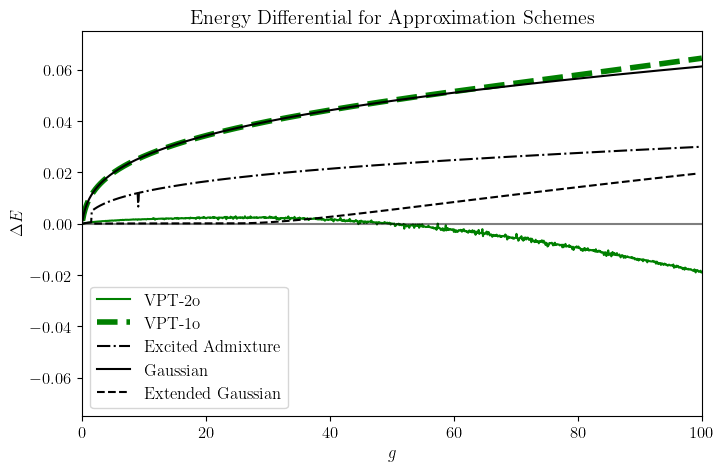

In [204]:
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(gvals, vpt_2o - exact, color='green', label='VPT-2o')
ax.plot(gvals, vpt_1o - exact, color='green', linestyle="--", linewidth=4, label='VPT-1o')
#ax.plot(gvals, var_energy_3 - exact, color='black', linestyle = "--", label='Extended Gaussian')
ax.plot(gvals, var_energy_2 - exact, color='black', linestyle = "-.", label='Excited Admixture')
ax.plot(gvals, var_energy_1 - exact, color='black', label='Gaussian')

#ax.plot(gvals, 0.011*np.log(gvals + 1.1), color='purple', label='$y = 0.011 \\ln \\hspace{1mm} (g + 1.1)$')

ax.plot(g3, var_energy_3 - exact3, color='black', linestyle = "--", label='Extended Gaussian')

#ax.plot(gvals, pert_2o - exact, color='blue')
#ax.plot(gvals, pert_1o - exact, color='blue', linestyle="--")

ax.set_title('Energy Differential for Approximation Schemes')
ax.set_ylabel('$\\Delta E$')
ax.set_xlabel('$g$')
ax.set_xlim([0, 100])
ax.set_ylim([-0.075, 0.075])

ax.axhline(0, color='black', alpha=0.5)
ax.legend()


Below I'm just doing some curve fitting by eye stuff. There seems to be a logarithmic relationship (polynomial family seems to grow too fast), but the logarithm eventually dies way quicker. It seems like $(\ln(x))^2$ is an even better fit but it also dies off too quickly near the end. Maybe it's some weird power of the natural logarithm or perhaps some polynomial in logarithms? Either way it's tiny. Every single function above shares this exact same form if you plot them out on their own which you can do yourself with the code here. So at the very least it looks like the answers roughly agree with the exact answer within $\ln(g)$ which is pretty good. 

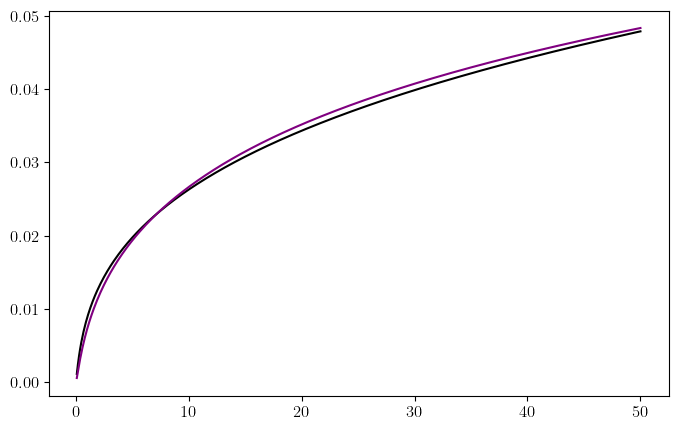

In [164]:
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(gvals, var_energy_1 - exact, color='black', label='Gaussian')

#ax.plot(gvals, 0.011*np.log(gvals + 1), color='purple', label='$y = 0.011 \\ln \\hspace{1mm} (g + 1.1)$')
ax.plot(gvals, 0.00125*np.log(10*gvals + 1)**2, color='purple')



Below is the stuff for setting up the $\omega$ vs $\Omega$ graph. It's weird. 

In [104]:
omega = np.arange(0.1, 20, 0.01)

Omega_1o = np.zeros_like(omega)
Omega_2o = np.zeros_like(omega)

for i in range(len(omega)):
    w = omega[i]
    Omega_1o[i] = sp.optimize.minimize(ground1, x0=[1.0]).x[0]
    Omega_2o[i] = sp.optimize.minimize(first_derivative_2o, x0=[1.0]).x[0]

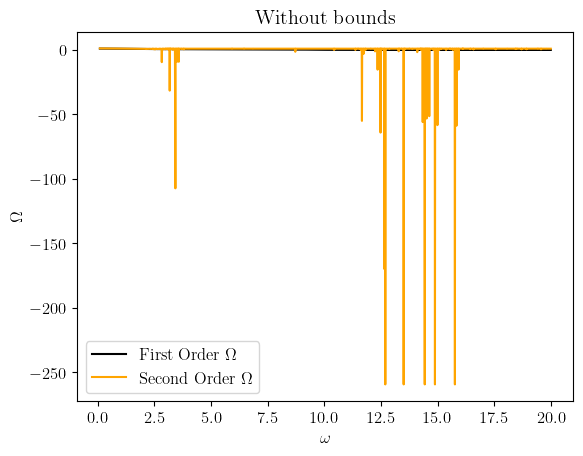

In [107]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)


ax.plot(omega, Omega_1o, label='First Order $\\Omega$', color='black')
ax.plot(omega, Omega_2o, label='Second Order $\\Omega$', color='orange')

#ax.set_ylim([0, 1.5])

ax.set_title('Without bounds')
ax.set_xlabel('$\\omega$')
ax.set_ylabel('$\\Omega$')


ax.legend()